# Resume Extraction Agent — Evaluation Notebook

**Objective**: Systematically test the resume extraction pipeline using:

- **10 hardcoded ground-truth test cases** (ML Engineer, Data Scientist, Backend Engineer, Frontend Engineer)
- **Field-level metrics**: Precision, Recall, F1 for list fields; Accuracy for string fields
- **LLM-as-Judge**: OpenRouter (Gemma) scores extraction quality out of 10 for real PDF resumes

---


## 1. Install Dependencies


In [ ]:
# Run this cell first — takes ~60s on fresh Colab
!pip install -q \
    pymupdf pymupdf4llm phonenumbers pydantic \
    langchain-google-genai langchain-openai openai \
    scikit-learn pandas tqdm tabulate matplotlib seaborn
print("Dependencies installed")

Dependencies installed


## 2. Configuration _(edit before running)_


In [ ]:
# ─────────────────────────────────────────────────────────────
# API KEYS  — replace with your actual keys
# ─────────────────────────────────────────────────────────────
GEMINI_API_KEYS = [
    "",
    "",
    "",
]

OPENROUTER_API_KEY   = ""  # LLM-as-judge

# ─────────────────────────────────────────────────────────────
# MODEL CONFIG
# ─────────────────────────────────────────────────────────────
# GEMINI_MODEL         = "gemini-2.5-flash"              # extraction backbone
GEMINI_MODEL         = "gemini-3.1-flash-lite"
JUDGE_MODEL          = "google/gemma-3-27b-it"         # OpenRouter judge model

# ─────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────
TESTDATA_DIR         = "/content/testdata"                     # upload PDFs here in Colab

# ─────────────────────────────────────────────────────────────
# EVAL CONFIG
# ─────────────────────────────────────────────────────────────
FUZZY_MATCH_THRESHOLD = 0.7   # string similarity threshold (0–1)
VERBOSE               = True  # print intermediate outputs

import os, warnings
warnings.filterwarnings("ignore")
os.makedirs(TESTDATA_DIR, exist_ok=True)
print("Config loaded")
print(f"   Extraction model : {GEMINI_MODEL}")
print(f"   Judge model      : {JUDGE_MODEL}")
print(f"   PDF directory    : {TESTDATA_DIR}")

Config loaded
   Extraction model : gemini-3.1-flash-lite
   Judge model      : google/gemma-3-27b-it
   PDF directory    : /content/testdata


## 3. Pydantic Schemas


In [ ]:
from pydantic import BaseModel, Field
from typing import Optional, Any, List

class ContactInfo(BaseModel):
    email:           Optional[str] = Field(default=None, description="Primary email address.")
    phone_raw:       Optional[str] = Field(default=None, description="Raw phone number as extracted.")
    country_code:    Optional[str] = Field(default=None, description="Country code (e.g., +91).")
    national_number: Optional[str] = Field(default=None, description="National number without country code.")
    e164_phone:      Optional[str] = Field(default=None, description="E.164 formatted phone number.")
    location:        Optional[str] = Field(default=None, description="Location such as city, state, or country.")
    linkedin:        Optional[str] = Field(default=None, description="LinkedIn profile URL.")
    github:          Optional[str] = Field(default=None, description="GitHub profile URL.")
    website:         Optional[str] = Field(default=None, description="Personal website or portfolio URL.")

class ExperienceItem(BaseModel):
    company:             Optional[str]  = Field(default=None)
    title:               Optional[str]  = Field(default=None)
    location:            Optional[str]  = Field(default=None)
    start_date:          Optional[str]  = Field(default=None)
    end_date:            Optional[str]  = Field(default=None)
    is_current:          Optional[bool] = Field(default=None)
    description_bullets: List[str]      = Field(default_factory=list)
    technologies:        List[str]      = Field(default_factory=list)

class EducationItem(BaseModel):
    institution:   Optional[str] = Field(default=None)
    degree:        Optional[str] = Field(default=None)
    field_of_study:Optional[str] = Field(default=None)
    start_date:    Optional[str] = Field(default=None)
    end_date:      Optional[str] = Field(default=None)
    grade:         Optional[str] = Field(default=None)
    notes:         List[str]     = Field(default_factory=list)

class ProjectItem(BaseModel):
    name:         Optional[str] = Field(default=None)
    description:  Optional[str] = Field(default=None)
    technologies: List[str]     = Field(default_factory=list)
    link:         Optional[str] = Field(default=None)

class CertificationItem(BaseModel):
    name:          Optional[str] = Field(default=None)
    issuer:        Optional[str] = Field(default=None)
    date:          Optional[str] = Field(default=None)
    credential_id: Optional[str] = Field(default=None)
    link:          Optional[str] = Field(default=None)

class ResumeExtraction(BaseModel):
    full_name:             Optional[str]            = Field(default=None)
    headline:              Optional[str]            = Field(default=None)
    contact:               ContactInfo              = Field(default_factory=ContactInfo)
    summary:               Optional[str]            = Field(default=None)
    skills:                List[str]                = Field(default_factory=list)
    programming_languages: List[str]                = Field(default_factory=list)
    spoken_languages:      List[str]                = Field(default_factory=list)
    experience:            List[ExperienceItem]     = Field(default_factory=list)
    education:             List[EducationItem]      = Field(default_factory=list)
    projects:              List[ProjectItem]        = Field(default_factory=list)
    certifications:        List[CertificationItem]  = Field(default_factory=list)
    keywords:              List[str]                = Field(default_factory=list)

print("Schemas defined")

Schemas defined


## 4. Core Utility Functions


In [ ]:
import re, json, tempfile, os
from urllib.parse import urlparse
import phonenumbers
from phonenumbers import PhoneNumberFormat

URL_TRAILING_PUNCT = ".,;:!?)]}>'\""
KNOWN_RESUME_TLDS = {
    "com","in","io","dev","net","org","ai","co",
    "me","app","tech","info","edu","gov",
}
COMMON_SKILL_TERMS = [
    "Python","Java","JavaScript","TypeScript","C++","C#","C","Go","Rust","SQL",
    "HTML","CSS","React","Next.js","Node.js","FastAPI","Django","Flask",
    "Pandas","NumPy","scikit-learn","TensorFlow","PyTorch","XGBoost","OpenCV",
    "AWS","GCP","Azure","Docker","Kubernetes","Git","Linux","Bash","Figma",
    "PostgreSQL","MongoDB","MySQL","Tableau","Power BI","Jira","Airflow","Spark",
]

def normalize_phone(raw_phone, default_region="IN"):
    if not raw_phone:
        return {"phone_raw":None,"country_code":None,"national_number":None,"e164_phone":None}
    try:
        parsed = phonenumbers.parse(raw_phone, default_region)
        if not phonenumbers.is_valid_number(parsed):
            return {"phone_raw":raw_phone,"country_code":None,"national_number":None,"e164_phone":None}
        return {
            "phone_raw":raw_phone,
            "country_code":f"+{parsed.country_code}",
            "national_number":str(parsed.national_number),
            "e164_phone":phonenumbers.format_number(parsed, PhoneNumberFormat.E164),
        }
    except Exception:
        return {"phone_raw":raw_phone,"country_code":None,"national_number":None,"e164_phone":None}

def normalize_text(text):
    text = text.replace("\r\n","\n").replace("\r","\n")
    text = re.sub(r"[ \t]+\n","\n",text)
    text = re.sub(r"\n{3,}","\n\n",text)
    text = re.sub(r"[ \t]{2,}"," ",text)
    return text.strip()

def strip_trailing_punctuation(url):
    url = url.strip()
    while url and url[-1] in URL_TRAILING_PUNCT:
        url = url[:-1]
    return url

def normalize_url(url):
    if not url: return None
    url = strip_trailing_punctuation(url.strip())
    if url.startswith("<") and url.endswith(">"): url = url[1:-1].strip()
    if url.lower().startswith("mailto:"): return None
    parsed = urlparse(url)
    candidate = None
    if parsed.scheme in {"http","https"} and parsed.netloc:
        candidate = url
    elif re.match(r"^(www\.)?([a-zA-Z0-9-]+\.)+[a-zA-Z]{2,}(/.*)?$",url):
        candidate = "https://" + url
    if not candidate: return None
    parsed_candidate = urlparse(candidate)
    host = (parsed_candidate.netloc or "").split(":")[0]
    if "." not in host: return None
    tld = host.rsplit(".",1)[-1].lower()
    if tld not in KNOWN_RESUME_TLDS: return None
    return candidate

def extract_urls_from_text(text):
    text = text or ""
    pattern = re.compile(r"""(?ix)(?<!@)\b(https?://[^\s<>()\[\]{}"']+|www\.[^\s<>()\[\]{}"']+|(?:[a-zA-Z0-9-]+\.)+[a-zA-Z]{2,}(?:/[^\s<>()\[\]{}"']+)?)""")
    found = []
    for match in pattern.finditer(text):
        url = normalize_url(match.group(1))
        if url: found.append(url)
    return list(dict.fromkeys(found))

def build_url_manifest(urls):
    manifest = []
    for url in urls:
        parsed = urlparse(url)
        u = url.lower()
        if "linkedin.com" in u: kind = "contact.linkedin"
        elif "github.com" in u: kind = "contact.github"
        else: kind = "other"
        manifest.append({"kind":kind,"url":url,"domain":parsed.netloc.lower() if parsed.netloc else ""})
    return json.dumps(manifest, ensure_ascii=False, indent=2)

print("Utility functions defined")

Utility functions defined


## 5. PDF Extraction Functions


In [ ]:
import fitz
import pymupdf4llm

def extract_embedded_urls(pdf_path):
    doc = fitz.open(pdf_path)
    urls = []
    for page in doc:
        for link in page.get_links():
            uri = normalize_url(link.get("uri"))
            if uri: urls.append(uri)
    return list(dict.fromkeys(urls))

def extract_pdf_text(pdf_path):
    try:
        text = pymupdf4llm.to_markdown(pdf_path, header=False, footer=False)
        text = normalize_text(text) if text and text.strip() else ""
    except Exception:
        text = ""
    if not text:
        doc = fitz.open(pdf_path)
        parts = [page.get_text("text", sort=True) for page in doc]
        text = normalize_text("\n\n".join(parts))
    embedded_urls = extract_embedded_urls(pdf_path)
    visible_urls  = extract_urls_from_text(text)
    all_urls = []
    seen = set()
    for url in embedded_urls + visible_urls:
        norm = normalize_url(url)
        if norm and norm not in seen:
            seen.add(norm)
            all_urls.append(norm)
    if all_urls:
        text += "\n\n[EXTRACTED_URLS_JSON]\n"
        text += build_url_manifest(all_urls)
        text += "\n[/EXTRACTED_URLS_JSON]"
    return text

def pdf_bytes_to_markdown(pdf_bytes):
    tf = tempfile.NamedTemporaryFile(suffix=".pdf", delete=False)
    temp_path = tf.name
    try:
        tf.write(pdf_bytes)
        tf.close()
        return extract_pdf_text(temp_path)
    finally:
        try: os.remove(temp_path)
        except OSError: pass

print("PDF extraction functions defined")

PDF extraction functions defined


## 6. LLM Factory


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from pydantic import ValidationError

from itertools import cycle
from threading import Lock

from langchain_google_genai import ChatGoogleGenerativeAI

# ───────────────────────────────────────────────────────────────
# API KEYS
# ───────────────────────────────────────────────────────────────

# Remove empty / None keys safely
GEMINI_API_KEYS = [k for k in GEMINI_API_KEYS if k]

if not GEMINI_API_KEYS:
    raise ValueError("No Gemini API keys configured")

# ───────────────────────────────────────────────────────────────
# ROUND-ROBIN KEY ROTATION
# ───────────────────────────────────────────────────────────────

_key_cycle = cycle(GEMINI_API_KEYS)
_key_lock = Lock()


def get_next_gemini_key():
    """
    Thread-safe round-robin API key rotation.
    """

    with _key_lock:
        return next(_key_cycle)


# ───────────────────────────────────────────────────────────────
# MODEL FACTORY
# ───────────────────────────────────────────────────────────────

def get_gemini_model(
    temperature=0.0,
    model=GEMINI_MODEL,
):
    return ChatGoogleGenerativeAI(
        model=model,
        google_api_key=get_next_gemini_key(),
        temperature=temperature,
        max_retries=0,   # IMPORTANT
    )

def get_openrouter_judge(temperature=0.1):
    return ChatOpenAI(
        model=JUDGE_MODEL,
        api_key=OPENROUTER_API_KEY,
        base_url="https://openrouter.ai/api/v1",
        temperature=temperature,
        default_headers={
            "HTTP-Referer": "https://resume-eval-notebook.local",
            "X-Title": "ResumeEvalNotebook",
        },
    )

def _strip_code_fences(text):
    text = (text or "").strip()
    text = re.sub(r"^```(?:json)?\s*","",text,flags=re.IGNORECASE)
    text = re.sub(r"\s*```$","",text,flags=re.IGNORECASE)
    return text.strip()

def _dedupe_strings(values):
    seen = set(); out = []
    for v in values:
        t = (v or "").strip()
        if t and t not in seen:
            seen.add(t); out.append(t)
    return out

def _infer_skills_from_text(resume_text):
    text = resume_text or ""; found = []; lowered = text.lower()
    for term in COMMON_SKILL_TERMS:
        idx = lowered.find(term.lower())
        if idx != -1: found.append((idx, term))
    found.sort(key=lambda x: x[0])
    return _dedupe_strings([t for _,t in found])

def _invoke_llm(prompt):
    model = get_gemini_model(temperature=0.0)
    response = model.invoke(prompt)
    content = getattr(response,"content","")
    if isinstance(content, str):
        raw_text = content
    elif isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, str): parts.append(item)
            elif isinstance(item, dict):
                mt = item.get("text")
                if isinstance(mt, str): parts.append(mt)
        raw_text = "\n".join(parts)
    else:
        raw_text = str(content or "")
    text = _strip_code_fences(raw_text)
    if not text: raise RuntimeError("Empty LLM response.")
    return text

print("LLM factory defined")

LLM factory defined


## 7. Extraction Pipeline


In [ ]:
def _stringify_list(value):
    items = []; seen = set()
    def add(item):
        if item is None: return
        if isinstance(item, str):
            chunks = re.split(r"[,\n;|/•·]+", item)
            if len(chunks) > 1:
                for c in chunks: add(c)
                return
            t = item.strip()
            if t and t not in seen: seen.add(t); items.append(t)
            return
        if isinstance(item, (int,float,bool)):
            t = str(item).strip()
            if t and t not in seen: seen.add(t); items.append(t)
            return
        if isinstance(item, list):
            for sub in item: add(sub)
            return
        if isinstance(item, dict):
            for k in ("name","title","skill","value","label","text"):
                val = item.get(k)
                if isinstance(val, str) and val.strip(): add(val); break
            for k in ("keywords","technologies","items","tags","values"):
                val = item.get(k)
                if isinstance(val, list):
                    for sub in val:
                        if isinstance(sub, str): add(sub)
                        else: add(sub)
    add(value); return items

def _normalize_blocks(blocks):
    out = []
    for b in blocks or []:
        if not isinstance(b, dict): continue
        item = dict(b)
        item["description_bullets"] = _stringify_list(item.get("description_bullets") or item.get("bullets") or item.get("achievements") or [])
        item["technologies"]        = _stringify_list(item.get("technologies") or item.get("tech") or item.get("tools") or [])
        out.append(item)
    return out

def _normalize_education(blocks):
    out = []
    for b in blocks or []:
        if not isinstance(b, dict): continue
        item = dict(b)
        item["notes"] = _stringify_list(item.get("notes") or item.get("coursework") or [])
        out.append(item)
    return out

def _normalize_projects(blocks):
    out = []
    for b in blocks or []:
        if not isinstance(b, dict): continue
        item = dict(b)
        if not item.get("name"): item["name"] = item.get("title") or item.get("project_name") or item.get("label")
        item["technologies"] = _stringify_list(item.get("technologies") or item.get("tech") or item.get("tools") or item.get("skills") or [])
        if not item.get("link"): item["link"] = item.get("url")
        out.append(item)
    return out

def parse_resume_json(candidate_json):
    raw = json.loads(_strip_code_fences(candidate_json))
    if not isinstance(raw, dict): raise ValueError("Resume JSON must be an object")
    raw["skills"]                = _stringify_list(raw.get("skills",[]))
    raw["programming_languages"] = _stringify_list(raw.get("programming_languages",[]))
    raw["spoken_languages"]      = _stringify_list(raw.get("spoken_languages",[]))
    raw["keywords"]              = _stringify_list(raw.get("keywords",[]))
    raw["experience"]            = _normalize_blocks(raw.get("experience",[]))
    raw["education"]             = _normalize_education(raw.get("education",[]))
    raw["projects"]              = _normalize_projects(raw.get("projects",[]))
    raw["certifications"]        = [i for i in raw.get("certifications",[]) if isinstance(i,dict)]
    return ResumeExtraction.model_validate(raw)

def _enforce_post_processing(parsed):
    d = parsed.model_dump(mode="json")
    c = d.get("contact",{}) or {}
    c.update(normalize_phone(c.get("phone_raw") or c.get("phone")))
    for f in ("linkedin","github","website"):
        c[f] = normalize_url(c.get(f))
    d["contact"] = c
    return ResumeExtraction.model_validate(d)

def _backfill_skills(parsed, resume_text):
    d = parsed.model_dump(mode="json")
    skills = _dedupe_strings(
        list(d.get("skills") or []) + list(d.get("programming_languages") or []) +
        list(d.get("spoken_languages") or []) + list(d.get("keywords") or [])
    )
    for exp in d.get("experience",[]) or []:
        if isinstance(exp,dict): skills.extend(_dedupe_strings(list(exp.get("technologies") or [])))
    for proj in d.get("projects",[]) or []:
        if isinstance(proj,dict): skills.extend(_dedupe_strings(list(proj.get("technologies") or [])))
    skills = _dedupe_strings(skills)
    if not skills: skills = _infer_skills_from_text(resume_text)
    d["skills"] = skills
    return ResumeExtraction.model_validate(d)

def build_extraction_prompt(resume_text):
    schema_json = json.dumps(ResumeExtraction.model_json_schema(), indent=2)
    return f"""You are a precise resume information extraction engine.

Return ONLY valid JSON matching the provided schema. No markdown. No prose. No code fences.
Do not invent facts. Use null where a value is unavailable.

--- TARGET JSON SCHEMA ---
{schema_json}

--- CLASSIFICATION RULES ---
programming_languages: Python, Java, C, C++, C#, JavaScript, TypeScript, Go, Rust, SQL, Bash, R, MATLAB, Scala, Swift, Kotlin, Dart
spoken_languages: English, Hindi, Marathi, Tamil, Telugu, Kannada, Bengali, French, German, Spanish, and similar human/natural languages
skills: all professional skills, core competencies, frameworks, libraries, platforms, tools, and databases

--- CONTACT RULES ---
phone_raw: copy the phone string exactly as it appears in the resume
For URLs: prefer the EXTRACTED_URLS_JSON manifest over inferred URLs
Do not guess or construct URLs that are not present

--- DATE RULES ---
Preserve dates as written. For ongoing roles set is_current=true and end_date="Present"

Resume text:
<<<BEGIN_RESUME_TEXT
{resume_text}
END_RESUME_TEXT>>>"""

def build_repair_prompt(resume_text, draft_json, validation_error):
    schema_json = json.dumps(ResumeExtraction.model_json_schema(), indent=2)
    return f"""You produced JSON that failed schema validation.
Fix it and return ONLY valid JSON. No markdown, no code fences.

--- SCHEMA ---
{schema_json}

Validation error:
{validation_error}

Previous JSON:
{draft_json}

Resume text:
<<<BEGIN_RESUME_TEXT
{resume_text}
END_RESUME_TEXT>>>"""

def extract_structured_resume_data(md_text):
    prompt = build_extraction_prompt(md_text)
    draft_json = _invoke_llm(prompt)
    for attempt in range(2):
        try:
            parsed = parse_resume_json(draft_json)
            parsed = _enforce_post_processing(parsed)
            parsed = _backfill_skills(parsed, md_text)
            return parsed
        except (ValidationError, json.JSONDecodeError, ValueError) as exc:
            if attempt == 0:
                print(f"  Validation failed, repairing... ({type(exc).__name__})")
                draft_json = _invoke_llm(build_repair_prompt(md_text, draft_json, str(exc)))
            else:
                raise
    raise RuntimeError("Extraction failed after repair.")

print("Extraction pipeline defined")

Extraction pipeline defined


## 8. Hardcoded Ground-Truth Test Cases

10 synthetic resumes with annotated ground truth across 4 job roles.  
Edge cases covered: sparse resume, missing phone, unicode characters, overlapping dates, no formal education, multi-location, ambiguous dates.


In [ ]:
TEST_CASES = [

    # ─── ML ENGINEER ───────────────────────────────────────────────────
    {
        "id": "ml-engineer-1",
        "role": "ml-engineer",
        "description": "Senior ML Engineer — well-structured, complete resume",
        "resume_text": """John Smith
ML Engineer | AI Researcher
john.smith@email.com | +1-555-010-1234 | San Francisco, CA
linkedin.com/in/johnsmith | github.com/johnsmith

SUMMARY
Experienced ML Engineer with 5 years building production ML systems at scale.

EXPERIENCE
Senior ML Engineer | TechCorp AI | San Francisco, CA | Jan 2021 - Present
- Designed transformer-based NLP models serving 10M+ daily requests
- Built MLOps pipeline using Kubeflow and MLflow reducing deployment time by 60%
- Technologies: Python, PyTorch, TensorFlow, Kubeflow, MLflow, AWS SageMaker, Docker, Kubernetes

ML Engineer | DataStartup | Remote | Jun 2019 - Dec 2020
- Built computer vision models for defect detection (95% accuracy)
- Technologies: Python, TensorFlow, OpenCV, Apache Spark, GCP

EDUCATION
M.S. Computer Science (Machine Learning) | Stanford University | 2017 - 2019 | GPA: 3.9
B.S. Computer Science | UC Berkeley | 2013 - 2017

SKILLS
Machine Learning, Deep Learning, NLP, Computer Vision, MLOps, System Design, A/B Testing

PROGRAMMING LANGUAGES
Python, C++, Java, SQL, R

CERTIFICATIONS
AWS Machine Learning Specialty | Amazon | 2021""",
        "expected": {
            "full_name": "John Smith",
            "headline": "ML Engineer | AI Researcher",
            "contact": {"email": "john.smith@email.com", "location": "San Francisco, CA"},
            "skills": ["Machine Learning", "Deep Learning", "NLP", "Computer Vision", "MLOps", "System Design", "A/B Testing"],
            "programming_languages": ["Python", "C++", "Java", "SQL", "R"],
            "experience_titles": ["Senior ML Engineer", "ML Engineer"],
            "experience_companies": ["TechCorp AI", "DataStartup"],
            "education_institutions": ["Stanford University", "UC Berkeley"],
            "certifications_names": ["AWS Machine Learning Specialty"],
            "has_summary": True,
            "current_role_present": True,
        }
    },

    {
        "id": "ml-engineer-2",
        "role": "ml-engineer",
        "description": "ML Engineer — NLP specialist, NO phone number (edge case)",
        "resume_text": """Priya Sharma
priya.sharma@ml.io | Bangalore, India
github.com/priyasharma-nlp | linkedin.com/in/priyasharma

OBJECTIVE
NLP engineer focused on large language models and multilingual systems.

EXPERIENCE
NLP Research Engineer | LanguageTech Pvt Ltd | Bangalore | Aug 2022 - Present
- Fine-tuned BERT, RoBERTa, and mBERT for 12 Indian languages
- Reduced inference latency by 40% via ONNX quantisation
- Technologies: Python, HuggingFace Transformers, PyTorch, ONNX, FastAPI

Junior ML Engineer | InfoSoft Solutions | Pune | Jul 2020 - Jul 2022
- Built sentiment analysis and text classification pipelines
- Technologies: Python, scikit-learn, NLTK, spaCy, Flask

EDUCATION
B.E. Computer Engineering | University of Pune | 2016 - 2020 | CGPA: 8.7/10

SKILLS
NLP, Large Language Models, Text Classification, Sentiment Analysis, Multilingual NLP, Model Quantisation

PROGRAMMING LANGUAGES
Python, SQL

SPOKEN LANGUAGES
English, Hindi, Marathi""",
        "expected": {
            "full_name": "Priya Sharma",
            "contact": {"email": "priya.sharma@ml.io", "location": "Bangalore, India", "phone_raw": None},
            "skills": ["NLP", "Large Language Models", "Text Classification", "Sentiment Analysis", "Multilingual NLP", "Model Quantisation"],
            "programming_languages": ["Python", "SQL"],
            "spoken_languages": ["English", "Hindi", "Marathi"],
            "experience_titles": ["NLP Research Engineer", "Junior ML Engineer"],
            "experience_companies": ["LanguageTech Pvt Ltd", "InfoSoft Solutions"],
            "education_institutions": ["University of Pune"],
            "current_role_present": True,
            "has_summary": True,  # objective counts as summary
        }
    },

    {
        "id": "ml-engineer-3",
        "role": "ml-engineer",
        "description": "Junior ML Engineer — fresh grad, sparse resume (edge case: minimal data)",
        "resume_text": """Alex Johnson
alexj@university.edu | New York, NY

EDUCATION
B.S. Data Science | NYU | 2020 - 2024

PROJECTS
Sentiment Classifier
Built a tweet sentiment classifier using BERT. Achieved 89% F1 score.
Technologies: Python, PyTorch, HuggingFace

Image Recognition App
CNN-based image classifier deployed on AWS Lambda.
Technologies: Python, TensorFlow, AWS Lambda

SKILLS
Machine Learning, Python, PyTorch, TensorFlow, Data Analysis""",
        "expected": {
            "full_name": "Alex Johnson",
            "contact": {"email": "alexj@university.edu", "location": "New York, NY"},
            "skills": ["Machine Learning", "Python", "PyTorch", "TensorFlow", "Data Analysis"],
            "programming_languages": ["Python"],
            "experience_titles": [],       # no work experience
            "experience_companies": [],
            "education_institutions": ["NYU"],
            "projects_names": ["Sentiment Classifier", "Image Recognition App"],
            "current_role_present": False,
            "has_summary": False,
        }
    },

    # ─── DATA SCIENTIST ─────────────────────────────────────────────────
    {
        "id": "data-scientist-1",
        "role": "data-scientist",
        "description": "Data Scientist — analytics heavy, multiple certs",
        "resume_text": """Maria Garcia
Data Scientist | Analytics Lead
maria.garcia@datasci.com | +34-612-345-678 | Madrid, Spain
linkedin.com/in/mariagarcia-ds | github.com/mgarcia-ds

PROFESSIONAL SUMMARY
Data Scientist with 6 years of experience turning raw data into business insights using ML and statistical methods.

EXPERIENCE
Senior Data Scientist | BankCo Analytics | Madrid | Mar 2020 - Present
- Built credit risk model reducing default rate by 18%
- Developed real-time fraud detection pipeline (0.3ms latency)
- Technologies: Python, XGBoost, LightGBM, SQL, Apache Kafka, Spark

Data Analyst | RetailChain | Barcelona | Jan 2018 - Feb 2020
- Automated weekly KPI dashboards saving 8 hours/week
- Technologies: Python, Pandas, Tableau, SQL, Excel

EDUCATION
M.Sc. Statistics | Universidad Complutense de Madrid | 2015 - 2017
B.Sc. Mathematics | Universidad de Barcelona | 2011 - 2015

SKILLS
Statistical Modeling, Machine Learning, A/B Testing, Feature Engineering, Data Visualization, Business Intelligence

PROGRAMMING LANGUAGES
Python, R, SQL

CERTIFICATIONS
Google Professional Data Engineer | Google Cloud | 2022
Tableau Desktop Specialist | Tableau | 2021""",
        "expected": {
            "full_name": "Maria Garcia",
            "headline": "Data Scientist | Analytics Lead",
            "contact": {"email": "maria.garcia@datasci.com", "location": "Madrid, Spain"},
            "skills": ["Statistical Modeling", "Machine Learning", "A/B Testing", "Feature Engineering", "Data Visualization", "Business Intelligence"],
            "programming_languages": ["Python", "R", "SQL"],
            "experience_titles": ["Senior Data Scientist", "Data Analyst"],
            "experience_companies": ["BankCo Analytics", "RetailChain"],
            "education_institutions": ["Universidad Complutense de Madrid", "Universidad de Barcelona"],
            "certifications_names": ["Google Professional Data Engineer", "Tableau Desktop Specialist"],
            "current_role_present": True,
            "has_summary": True,
        }
    },

    {
        "id": "data-scientist-2",
        "role": "data-scientist",
        "description": "Data Scientist — ambiguous dates, gap in employment (edge case)",
        "resume_text": """Chen Wei
Data Scientist
chen.wei@outlook.com | +86-138-0000-1234 | Shanghai, China

ABOUT
Passionate data scientist specialising in time-series forecasting and supply-chain optimisation.

EXPERIENCE
Data Scientist | LogisticsCo | Shanghai | 2021 - Present
- Forecasting models for 5,000 SKUs reducing stockouts by 22%
- Technologies: Python, Prophet, statsmodels, SQL, Airflow

Freelance Data Consultant | Self-employed | Remote | 2019 - 2021
- Consulting for 3 SMEs on data strategy and BI dashboards
- Technologies: Python, Tableau, Power BI, SQL

Data Analyst Intern | FinTechCo | Beijing | Summer 2018
- Cleaned and visualized customer transaction data
- Technologies: Python, Excel, SQL

EDUCATION
B.Sc. Applied Mathematics | Peking University | 2015 - 2019

SKILLS
Time-Series Forecasting, Supply Chain Analytics, EDA, Data Storytelling, Model Monitoring

PROGRAMMING LANGUAGES
Python, SQL, MATLAB""",
        "expected": {
            "full_name": "Chen Wei",
            "contact": {"email": "chen.wei@outlook.com", "location": "Shanghai, China"},
            "skills": ["Time-Series Forecasting", "Supply Chain Analytics", "EDA", "Data Storytelling", "Model Monitoring"],
            "programming_languages": ["Python", "SQL", "MATLAB"],
            "experience_titles": ["Data Scientist", "Freelance Data Consultant", "Data Analyst Intern"],
            "experience_companies": ["LogisticsCo", "Self-employed", "FinTechCo"],
            "education_institutions": ["Peking University"],
            "current_role_present": True,
            "has_summary": True,
        }
    },

    # ─── BACKEND ENGINEER ───────────────────────────────────────────────
    {
        "id": "backend-engineer-1",
        "role": "backend-engineer",
        "description": "Backend Engineer — Python/FastAPI, microservices",
        "resume_text": """Rahul Mehta
Backend Software Engineer
rahul.mehta@gmail.com | +91-98765-43210 | Mumbai, India
github.com/rahulmehta | linkedin.com/in/rahulmehta-be

SUMMARY
Backend engineer with 4 years of experience building scalable APIs and microservices using Python and cloud-native technologies.

EXPERIENCE
Software Engineer II | FinApp Pvt Ltd | Mumbai | Apr 2022 - Present
- Designed REST APIs handling 50k RPM using FastAPI and PostgreSQL
- Implemented event-driven architecture with Apache Kafka
- Technologies: Python, FastAPI, PostgreSQL, Redis, Kafka, Docker, AWS, Terraform

Software Engineer | WebSolutions | Pune | Jun 2020 - Mar 2022
- Built Django REST APIs for e-commerce platform serving 100k users
- Technologies: Python, Django, MySQL, Redis, Celery, Nginx

EDUCATION
B.Tech Computer Science | IIT Bombay | 2016 - 2020 | CGPA: 8.5/10

SKILLS
REST API Design, Microservices, System Design, Database Optimisation, CI/CD, Agile

PROGRAMMING LANGUAGES
Python, SQL, Bash, Go

CERTIFICATIONS
AWS Solutions Architect Associate | Amazon | 2023""",
        "expected": {
            "full_name": "Rahul Mehta",
            "headline": "Backend Software Engineer",
            "contact": {"email": "rahul.mehta@gmail.com", "location": "Mumbai, India"},
            "skills": ["REST API Design", "Microservices", "System Design", "Database Optimisation", "CI/CD", "Agile"],
            "programming_languages": ["Python", "SQL", "Bash", "Go"],
            "experience_titles": ["Software Engineer II", "Software Engineer"],
            "experience_companies": ["FinApp Pvt Ltd", "WebSolutions"],
            "education_institutions": ["IIT Bombay"],
            "certifications_names": ["AWS Solutions Architect Associate"],
            "current_role_present": True,
            "has_summary": True,
        }
    },

    {
        "id": "backend-engineer-2",
        "role": "backend-engineer",
        "description": "Backend Engineer — Java/Spring, enterprise stack (edge case: long career)",
        "resume_text": """Dmitri Volkov
Senior Backend Engineer
dmitri.volkov@corp.ru | +7-916-123-4567 | Moscow, Russia
linkedin.com/in/dmitrivolkov

PROFESSIONAL PROFILE
15+ years building enterprise-grade Java backend systems for banking and insurance.

EXPERIENCE
Lead Backend Engineer | BankRu Systems | Moscow | Jan 2016 - Present
- Architected microservices migration from monolith (Spring Boot, Kubernetes)
- Technologies: Java, Spring Boot, Hibernate, PostgreSQL, RabbitMQ, Kubernetes, Docker

Senior Java Developer | InsureCo | St. Petersburg | Mar 2012 - Dec 2015
- Core banking transaction processing system (99.99% uptime SLA)
- Technologies: Java, Spring MVC, Oracle DB, JMS, Maven

Java Developer | SoftwareLab | Moscow | Aug 2008 - Feb 2012
- Developed internal HR management system
- Technologies: Java, JSF, Hibernate, MySQL

EDUCATION
M.Sc. Computer Science | Moscow State University | 2003 - 2008

SKILLS
Enterprise Architecture, Microservices, Distributed Systems, TDD, Code Review, Mentoring

PROGRAMMING LANGUAGES
Java, SQL, Kotlin, Bash""",
        "expected": {
            "full_name": "Dmitri Volkov",
            "headline": "Senior Backend Engineer",
            "contact": {"email": "dmitri.volkov@corp.ru", "location": "Moscow, Russia"},
            "skills": ["Enterprise Architecture", "Microservices", "Distributed Systems", "TDD", "Code Review", "Mentoring"],
            "programming_languages": ["Java", "SQL", "Kotlin", "Bash"],
            "experience_titles": ["Lead Backend Engineer", "Senior Java Developer", "Java Developer"],
            "experience_companies": ["BankRu Systems", "InsureCo", "SoftwareLab"],
            "education_institutions": ["Moscow State University"],
            "current_role_present": True,
            "has_summary": True,
        }
    },

    {
        "id": "backend-engineer-3",
        "role": "backend-engineer",
        "description": "Backend Engineer — NO formal education listed (edge case)",
        "resume_text": """Sam Torres
Backend Developer | Open Source Contributor
sam@torres.dev | github.com/samtor | Austin, TX

ABOUT
Self-taught developer with 7 years of backend experience. Active open-source contributor to Node.js ecosystem.

EXPERIENCE
Backend Engineer | CloudScale Inc | Austin, TX | 2020 - Present
- Built GraphQL APIs serving 2M users, Node.js + TypeScript
- Reduced P99 latency from 800ms to 120ms via caching strategy
- Technologies: Node.js, TypeScript, GraphQL, PostgreSQL, Redis, AWS, Terraform

Junior Backend Developer | LocalStartup | Austin, TX | 2017 - 2020
- REST API development for SaaS product
- Technologies: Node.js, Express.js, MongoDB, Docker

SKILLS
GraphQL, REST APIs, Caching Strategies, Performance Optimisation, Open Source Development, DevOps

PROGRAMMING LANGUAGES
JavaScript, TypeScript, SQL, Bash

PROJECTS
graphql-perf-toolkit (github.com/samtor/graphql-perf-toolkit)
Open source toolkit for GraphQL performance profiling. 1.2k GitHub stars.
Technologies: TypeScript, Node.js, GraphQL""",
        "expected": {
            "full_name": "Sam Torres",
            "contact": {"email": "sam@torres.dev", "location": "Austin, TX"},
            "skills": ["GraphQL", "REST APIs", "Caching Strategies", "Performance Optimisation", "Open Source Development", "DevOps"],
            "programming_languages": ["JavaScript", "TypeScript", "SQL", "Bash"],
            "experience_titles": ["Backend Engineer", "Junior Backend Developer"],
            "experience_companies": ["CloudScale Inc", "LocalStartup"],
            "education_institutions": [],   # self-taught, no formal edu
            "projects_names": ["graphql-perf-toolkit"],
            "current_role_present": True,
            "has_summary": True,
        }
    },

    # ─── FRONTEND ENGINEER ──────────────────────────────────────────────
    {
        "id": "frontend-engineer-1",
        "role": "frontend-engineer",
        "description": "Frontend Engineer — React/TypeScript, design system experience",
        "resume_text": """Aisha Okonkwo
Frontend Engineer | UI/UX Enthusiast
aisha.okonkwo@email.com | +234-802-000-1234 | Lagos, Nigeria
linkedin.com/in/aishaokonkwo | github.com/aishao | aishaokonkwo.dev

SUMMARY
Frontend engineer with 5 years of experience building performant React applications and design systems.

EXPERIENCE
Senior Frontend Engineer | FinTech Lagos | Lagos | Feb 2021 - Present
- Led migration from AngularJS to React 18, improving performance by 35%
- Built shared component library used across 6 product teams
- Technologies: React, TypeScript, Next.js, Storybook, Figma, Tailwind CSS, Jest

Frontend Engineer | MediaCo | Abuja | Jul 2018 - Jan 2021
- Developed responsive news platform serving 500k monthly users
- Technologies: React, JavaScript, CSS3, Webpack, GraphQL, REST APIs

EDUCATION
B.Sc. Computer Science | University of Lagos | 2014 - 2018

SKILLS
Component Architecture, Design Systems, Web Performance, Accessibility (WCAG), Cross-Browser Compatibility, Responsive Design

PROGRAMMING LANGUAGES
JavaScript, TypeScript, HTML, CSS""",
        "expected": {
            "full_name": "Aisha Okonkwo",
            "headline": "Frontend Engineer | UI/UX Enthusiast",
            "contact": {"email": "aisha.okonkwo@email.com", "location": "Lagos, Nigeria"},
            "skills": ["Component Architecture", "Design Systems", "Web Performance", "Accessibility (WCAG)", "Cross-Browser Compatibility", "Responsive Design"],
            "programming_languages": ["JavaScript", "TypeScript", "HTML", "CSS"],
            "experience_titles": ["Senior Frontend Engineer", "Frontend Engineer"],
            "experience_companies": ["FinTech Lagos", "MediaCo"],
            "education_institutions": ["University of Lagos"],
            "current_role_present": True,
            "has_summary": True,
        }
    },

    {
        "id": "frontend-engineer-2",
        "role": "frontend-engineer",
        "description": "Frontend Engineer — edge case: unicode name, career change, overlapping side project",
        "resume_text": """Søren Møller
Frontend Developer
soren.moller@dev.io | Copenhagen, Denmark | +45-31-23-45-67
github.com/sorenmoller | linkedin.com/in/sorenmoller

ABOUT ME
Former graphic designer turned frontend developer. 3 years in tech after 4 years in design.

EXPERIENCE
Frontend Developer | DesignTechCo | Copenhagen | Jan 2022 - Present
- Built accessibility-first React interfaces for public-sector clients (WCAG 2.1 AA)
- Technologies: React, JavaScript, CSS Modules, ARIA, Figma, Storybook

Freelance Web Developer | Self-employed | Remote | Mar 2020 - Dec 2021
- Delivered 15+ client websites
- Technologies: HTML, CSS, JavaScript, WordPress, Webflow

Graphic Designer | CreativeAgency | Copenhagen | 2016 - 2020
- Brand identity and print design (not tech role)

EDUCATION
Web Development Bootcamp | Coded Academy | 2020 | Certificate
B.A. Graphic Design | Royal Danish Academy | 2012 - 2016

SKILLS
Accessibility, UI Design, Design-to-Code, Responsive Design, CSS Animation, Figma-to-React

PROGRAMMING LANGUAGES
JavaScript, HTML, CSS

SPOKEN LANGUAGES
Danish, English, German""",
        "expected": {
            "full_name": "Søren Møller",
            "contact": {"email": "soren.moller@dev.io", "location": "Copenhagen, Denmark"},
            "skills": ["Accessibility", "UI Design", "Design-to-Code", "Responsive Design", "CSS Animation", "Figma-to-React"],
            "programming_languages": ["JavaScript", "HTML", "CSS"],
            "spoken_languages": ["Danish", "English", "German"],
            "experience_titles": ["Frontend Developer", "Freelance Web Developer", "Graphic Designer"],
            "experience_companies": ["DesignTechCo", "Self-employed", "CreativeAgency"],
            "education_institutions": ["Coded Academy", "Royal Danish Academy"],
            "current_role_present": True,
            "has_summary": True,
        }
    },
]

print(f"{len(TEST_CASES)} test cases loaded")
for tc in TEST_CASES:
    print(f"   [{tc['id']}] {tc['description']}")


10 test cases loaded
   [ml-engineer-1] Senior ML Engineer — well-structured, complete resume
   [ml-engineer-2] ML Engineer — NLP specialist, NO phone number (edge case)
   [ml-engineer-3] Junior ML Engineer — fresh grad, sparse resume (edge case: minimal data)
   [data-scientist-1] Data Scientist — analytics heavy, multiple certs
   [data-scientist-2] Data Scientist — ambiguous dates, gap in employment (edge case)
   [backend-engineer-1] Backend Engineer — Python/FastAPI, microservices
   [backend-engineer-2] Backend Engineer — Java/Spring, enterprise stack (edge case: long career)
   [backend-engineer-3] Backend Engineer — NO formal education listed (edge case)
   [frontend-engineer-1] Frontend Engineer — React/TypeScript, design system experience
   [frontend-engineer-2] Frontend Engineer — edge case: unicode name, career change, overlapping side project


## 9. Evaluation Metric Functions

- **List fields** (skills, languages, etc.): token-normalised **Precision / Recall / F1**
- **String fields** (name, email, location): **exact match** after normalisation
- **Structured fields** (experience, education): best-match via **token overlap**
- **Boolean fields** (current_role_present, has_summary): exact match accuracy


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import difflib

def norm(s):
    "Lowercase, strip whitespace for comparison."
    return (s or "").lower().strip()

def token_set(lst):
    "Normalised set of strings from a list."
    return {norm(x) for x in (lst or []) if x and norm(x)}

def list_field_metrics(pred_list, true_list):
    "Precision / Recall / F1 for two lists (set-based)."
    pred = token_set(pred_list)
    true = token_set(true_list)
    if not true and not pred:
        return {"precision": 1.0, "recall": 1.0, "f1": 1.0}
    if not true:
        return {"precision": 0.0, "recall": 1.0, "f1": 0.0}
    if not pred:
        return {"precision": 1.0, "recall": 0.0, "f1": 0.0}
    tp = len(pred & true)
    precision = tp / len(pred) if pred else 0.0
    recall    = tp / len(true) if true else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return {"precision": round(precision, 4), "recall": round(recall, 4), "f1": round(f1, 4)}

def string_match(pred_str, true_str, fuzzy=False, threshold=FUZZY_MATCH_THRESHOLD):
    "Returns 1.0 for match, 0.0 for mismatch."
    p, t = norm(pred_str), norm(true_str)
    if t == "": return 1.0  # expected empty → always correct
    if not p:   return 0.0
    if p == t:  return 1.0
    if fuzzy:
        ratio = difflib.SequenceMatcher(None, p, t).ratio()
        return 1.0 if ratio >= threshold else 0.0
    return 0.0

def best_match_overlap(pred_items, true_items, key_fn):
    '''
    For each expected item, find the best-matching predicted item by key overlap.
    Returns recall-style score (fraction of expected items that were found).
    '''
    if not true_items: return 1.0
    found = 0
    used = set()
    for ti in true_items:
        t_key = norm(key_fn(ti))
        best_score = 0.0
        best_idx = -1
        for pi_idx, pi in enumerate(pred_items):
            if pi_idx in used: continue
            p_key = norm(key_fn(pi))
            score = difflib.SequenceMatcher(None, p_key, t_key).ratio()
            if score > best_score:
                best_score = score
                best_idx = pi_idx
        if best_score >= FUZZY_MATCH_THRESHOLD:
            found += 1
            if best_idx >= 0: used.add(best_idx)
    return found / len(true_items)

def evaluate_single(extracted: ResumeExtraction, expected: dict) -> dict:
    '''
    Compare one extraction result against its ground truth.
    Returns a dict of per-field scores and an overall score.
    '''
    d = extracted.model_dump(mode="json")
    contact = d.get("contact") or {}
    results = {}

    # ── String fields ──────────────────────────────────────────────────
    results["full_name"]  = string_match(d.get("full_name"),  expected.get("full_name"),  fuzzy=True)
    results["headline"]   = string_match(d.get("headline"),   expected.get("headline"),   fuzzy=True)
    results["has_summary"]= 1.0 if bool(d.get("summary")) == expected.get("has_summary", False) else 0.0

    # ── Contact fields ─────────────────────────────────────────────────
    exp_contact = expected.get("contact", {})
    results["email"]      = string_match(contact.get("email"),    exp_contact.get("email"))
    results["location"]   = string_match(contact.get("location"), exp_contact.get("location"), fuzzy=True)

    # Phone: expected None means we expect no phone
    if exp_contact.get("phone_raw") is None:
        results["phone"]  = 1.0 if not contact.get("phone_raw") else 0.0
    else:
        results["phone"]  = 1.0 if contact.get("phone_raw") else 0.0

    # ── List fields ────────────────────────────────────────────────────
    m_skills = list_field_metrics(d.get("skills", []),                 expected.get("skills", []))
    m_prg    = list_field_metrics(d.get("programming_languages", []),  expected.get("programming_languages", []))
    m_spk    = list_field_metrics(d.get("spoken_languages", []),       expected.get("spoken_languages", []))

    results["skills_precision"]  = m_skills["precision"]
    results["skills_recall"]     = m_skills["recall"]
    results["skills_f1"]         = m_skills["f1"]

    results["prog_lang_precision"] = m_prg["precision"]
    results["prog_lang_recall"]    = m_prg["recall"]
    results["prog_lang_f1"]        = m_prg["f1"]

    results["spoken_lang_f1"]    = m_spk["f1"]

    # ── Experience ─────────────────────────────────────────────────────
    exp_titles    = expected.get("experience_titles", [])
    exp_companies = expected.get("experience_companies", [])
    pred_exps     = d.get("experience", [])

    results["exp_title_recall"]   = best_match_overlap(
        pred_exps, exp_titles,   lambda x: x.get("title","") if isinstance(x,dict) else x)
    results["exp_company_recall"] = best_match_overlap(
        pred_exps, exp_companies, lambda x: x.get("company","") if isinstance(x,dict) else x)

    # current role detection
    if "current_role_present" in expected:
        has_current = any(e.get("is_current") or norm(e.get("end_date","")) in {"present","current","now"}
                          for e in pred_exps if isinstance(e, dict))
        results["current_role"] = 1.0 if has_current == expected["current_role_present"] else 0.0

    # ── Education ──────────────────────────────────────────────────────
    exp_edu = expected.get("education_institutions", [])
    pred_edu = d.get("education", [])
    results["education_recall"] = best_match_overlap(
        pred_edu, exp_edu, lambda x: x.get("institution","") if isinstance(x,dict) else x)

    # ── Projects ───────────────────────────────────────────────────────
    exp_proj = expected.get("projects_names", [])
    if exp_proj:
        pred_proj = d.get("projects", [])
        results["projects_recall"] = best_match_overlap(
            pred_proj, exp_proj, lambda x: x.get("name","") if isinstance(x,dict) else x)

    # ── Certifications ─────────────────────────────────────────────────
    exp_certs = expected.get("certifications_names", [])
    if exp_certs:
        pred_certs = d.get("certifications", [])
        results["cert_recall"] = best_match_overlap(
            pred_certs, exp_certs, lambda x: x.get("name","") if isinstance(x,dict) else x)

    # ── Overall score (weighted mean) ───────────────────────────────────
    weight_map = {
        "full_name": 2.0, "email": 2.0, "location": 1.5,
        "has_summary": 1.0, "headline": 1.0, "phone": 1.0,
        "skills_f1": 3.0, "prog_lang_f1": 2.0, "spoken_lang_f1": 1.0,
        "exp_title_recall": 2.5, "exp_company_recall": 2.5,
        "education_recall": 2.0, "current_role": 1.5,
        "projects_recall": 1.5, "cert_recall": 1.5,
    }
    total_w = total_wv = 0.0
    for k, w in weight_map.items():
        if k in results:
            total_w  += w
            total_wv += w * results[k]
    results["overall_score"] = round(total_wv / total_w, 4) if total_w else 0.0
    return results

print("Evaluation metrics defined")

Evaluation metrics defined


## 10. Run Evaluation on Hardcoded Test Cases


In [ ]:
import time
import random
import traceback
import pandas as pd
from tqdm import tqdm

# ───────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────

MAX_RETRIES = 6                 # exponential backoff retries
BASE_DELAY = 5                  # initial retry delay (seconds)
POST_EVAL_DELAY = (10, 15)      # random cooldown between resumes
VERBOSE = True

# ───────────────────────────────────────────────────────────────
# RETRY WRAPPER
# ───────────────────────────────────────────────────────────────

def extract_with_retry(resume_text):
    """
    Calls extract_structured_resume_data with exponential backoff.
    Handles Gemini free-tier rate limits and transient failures.
    """

    last_exception = None

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return extract_structured_resume_data(resume_text)

        except Exception as e:
            last_exception = e
            err_text = str(e).lower()

            # Detect rate limit / quota style failures
            retryable = any(keyword in err_text for keyword in [
                "429",
                "quota",
                "rate limit",
                "resource exhausted",
                "too many requests",
                "deadline exceeded",
                "internal",
                "temporarily unavailable",
                "service unavailable",
                "timeout",
            ])

            if not retryable:
                raise

            if attempt == MAX_RETRIES:
                break

            # Exponential backoff with jitter
            delay = BASE_DELAY * (2 ** (attempt - 1))
            jitter = random.uniform(0.5, 2.0)
            sleep_time = delay + jitter

            print(
                f"   ⚠ Retry {attempt}/{MAX_RETRIES} "
                f"after {sleep_time:.1f}s | {type(e).__name__}: {e}"
            )

            time.sleep(sleep_time)

    raise last_exception


# ───────────────────────────────────────────────────────────────
# MAIN EVALUATION LOOP
# ───────────────────────────────────────────────────────────────

def run_test_cases(test_cases, verbose=VERBOSE):
    results = []

    for idx, tc in enumerate(
        tqdm(test_cases, desc="Evaluating test cases"),
        start=1
    ):
        tc_id = tc["id"]

        if verbose:
            print(f"\n{'=' * 60}")

        print(f"▶ [{idx}/{len(test_cases)}] [{tc_id}] {tc['description']}")

        try:
            # extraction with retry + backoff
            extracted = extract_with_retry(tc["resume_text"])

            # evaluation
            scores = evaluate_single(extracted, tc["expected"])

            if verbose:
                print(f"   full_name     : {extracted.full_name!r}")
                print(f"   email         : {extracted.contact.email!r}")
                print(
                    f"   skills        : "
                    f"{extracted.skills[:5]}"
                    f"{'...' if len(extracted.skills) > 5 else ''}"
                )
                print(f"   prog_langs    : {extracted.programming_languages}")
                print(f"   exp count     : {len(extracted.experience)}")
                print(f"   overall_score : {scores['overall_score']:.4f}")

            results.append({
                "id": tc_id,
                "role": tc["role"],
                "status": "ok",
                **scores
            })

        except Exception as e:
            print(f"   ❌ FAILED: {type(e).__name__}: {e}")

            if verbose:
                traceback.print_exc()

            results.append({
                "id": tc_id,
                "role": tc["role"],
                "status": "error",
                "overall_score": 0.0
            })

        # cooldown after each resume
        if idx < len(test_cases):
            cooldown = random.randint(*POST_EVAL_DELAY)
            print(f"   ⏳ Cooling down for {cooldown}s...")
            time.sleep(cooldown)

    return results


# ───────────────────────────────────────────────────────────────
# RUN
# ───────────────────────────────────────────────────────────────

print("🔄 Running extraction + evaluation on test cases...")
print("   (Gemini API free-tier safe mode enabled)\n")

start_time = time.time()

eval_results = run_test_cases(TEST_CASES)

elapsed = time.time() - start_time

print("\n✅ Evaluation complete")
print(f"⏱ Total runtime: {elapsed/60:.2f} min")

# Optional dataframe
results_df = pd.DataFrame(eval_results)

print("\nSummary:")
print(results_df[["id", "role", "status", "overall_score"]])

🔄 Running extraction + evaluation on test cases...
   (Gemini API free-tier safe mode enabled)



Evaluating test cases:   0%|          | 0/10 [00:00<?, ?it/s]


▶ [1/10] [ml-engineer-1] Senior ML Engineer — well-structured, complete resume
   full_name     : 'John Smith'
   email         : 'john.smith@email.com'
   skills        : ['Machine Learning', 'Deep Learning', 'NLP', 'Computer Vision', 'MLOps']...
   prog_langs    : ['Python', 'C++', 'Java', 'SQL', 'R']
   exp count     : 2
   overall_score : 0.8813
   ⏳ Cooling down for 14s...


Evaluating test cases:  10%|█         | 1/10 [00:24<03:38, 24.25s/it]


▶ [2/10] [ml-engineer-2] ML Engineer — NLP specialist, NO phone number (edge case)
   full_name     : 'Priya Sharma'
   email         : 'priya.sharma@ml.io'
   skills        : ['NLP', 'Large Language Models', 'Text Classification', 'Sentiment Analysis', 'Multilingual NLP']...
   prog_langs    : ['Python', 'SQL']
   exp count     : 2
   overall_score : 0.9275
   ⏳ Cooling down for 13s...


...


▶ [9/10] [frontend-engineer-1] Frontend Engineer — React/TypeScript, design system experience
   full_name     : 'Aisha Okonkwo'
   email         : 'aisha.okonkwo@email.com'
   skills        : ['Component Architecture', 'Design Systems', 'Web Performance', 'Accessibility (WCAG)', 'Cross-Browser Compatibility']...
   prog_langs    : ['JavaScript', 'TypeScript', 'HTML', 'CSS']
   exp count     : 2
   overall_score : 0.8863
   ⏳ Cooling down for 10s...


Evaluating test cases:  90%|█████████ | 9/10 [04:03<00:28, 28.47s/it]


▶ [10/10] [frontend-engineer-2] Frontend Engineer — edge case: unicode name, career change, overlapping side project


Evaluating test cases: 100%|██████████| 10/10 [04:38<00:00, 27.83s/it]

   full_name     : 'Søren Møller'
   email         : 'soren.moller@dev.io'
   skills        : ['Accessibility', 'UI Design', 'Design-to-Code', 'Responsive Design', 'CSS Animation']...
   prog_langs    : ['JavaScript', 'HTML', 'CSS']
   exp count     : 3
   overall_score : 0.8841

✅ Evaluation complete
⏱ Total runtime: 4.64 min

Summary:
                    id               role status  overall_score
0        ml-engineer-1        ml-engineer     ok         0.8813
1        ml-engineer-2        ml-engineer     ok         0.9275
2        ml-engineer-3        ml-engineer     ok         0.9496
3     data-scientist-1     data-scientist     ok         0.8790
4     data-scientist-2     data-scientist     ok         0.8828
5   backend-engineer-1   backend-engineer     ok         0.8775
6   backend-engineer-2   backend-engineer     ok         0.8801
7   backend-engineer-3   backend-engineer     ok         0.9300
8  frontend-engineer-1  frontend-engineer     ok         0.8863
9  frontend-engineer-


EVALUATION RESULTS — HARDCODED TEST CASES
                 id              role status  overall_score  full_name  email  skills_f1  prog_lang_f1  exp_title_recall  exp_company_recall  education_recall
      ml-engineer-1       ml-engineer     ok          0.881      1.000  1.000      0.364         1.000             1.000               1.000             1.000
      ml-engineer-2       ml-engineer     ok          0.927      1.000  1.000      0.444         1.000             1.000               1.000             1.000
      ml-engineer-3       ml-engineer     ok          0.950      1.000  1.000      0.588         1.000             1.000               1.000             1.000
   data-scientist-1    data-scientist     ok          0.879      1.000  1.000      0.345         1.000             1.000               1.000             1.000
   data-scientist-2    data-scientist     ok          0.883      1.000  1.000      0.435         1.000             1.000               1.000             1.000
 ba

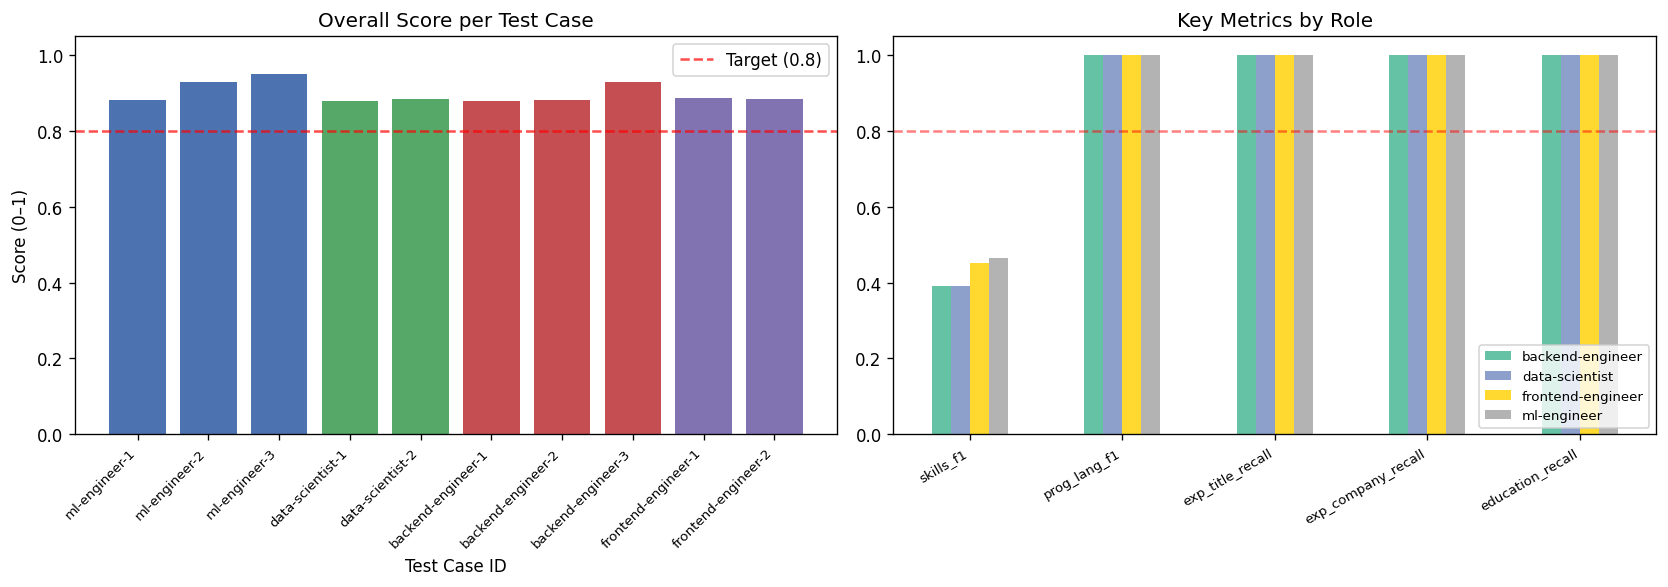

Chart saved to eval_summary.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

df = pd.DataFrame(eval_results)
print("\n" + "="*70)
print("EVALUATION RESULTS — HARDCODED TEST CASES")
print("="*70)

# Key columns to display
display_cols = [
    "id","role","status","overall_score",
    "full_name","email","skills_f1","prog_lang_f1",
    "exp_title_recall","exp_company_recall","education_recall",
]
display_cols = [c for c in display_cols if c in df.columns]
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print(df[display_cols].to_string(index=False))

print("\n── AVERAGE SCORES BY ROLE ──")
role_summary = df.groupby("role")[["overall_score","skills_f1","prog_lang_f1",
                                    "exp_title_recall","exp_company_recall","education_recall"]].mean()
print(role_summary.round(3).to_string())

print(f"\n── GRAND MEAN overall_score : {df['overall_score'].mean():.4f} ──")

# ─── Bar chart: overall score per test case ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"ml-engineer":"#4C72B0","data-scientist":"#55A868",
          "backend-engineer":"#C44E52","frontend-engineer":"#8172B2"}
bar_colors = [colors.get(r,"#666") for r in df["role"]]

axes[0].bar(df["id"], df["overall_score"], color=bar_colors)
axes[0].axhline(0.8, color="red", linestyle="--", alpha=0.7, label="Target (0.8)")
axes[0].set_title("Overall Score per Test Case")
axes[0].set_xlabel("Test Case ID")
axes[0].set_ylabel("Score (0–1)")
axes[0].set_xticklabels(df["id"], rotation=45, ha="right", fontsize=8)
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Radar / grouped bar per role
metric_cols = ["skills_f1","prog_lang_f1","exp_title_recall","exp_company_recall","education_recall"]
metric_cols = [c for c in metric_cols if c in role_summary.columns]
role_summary[metric_cols].T.plot(kind="bar", ax=axes[1], colormap="Set2")
axes[1].set_title("Key Metrics by Role")
axes[1].set_xticklabels(metric_cols, rotation=30, ha="right", fontsize=8)
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="lower right", fontsize=8)
axes[1].axhline(0.8, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("eval_summary.png", bbox_inches="tight")
plt.show()
print("Chart saved to eval_summary.png")

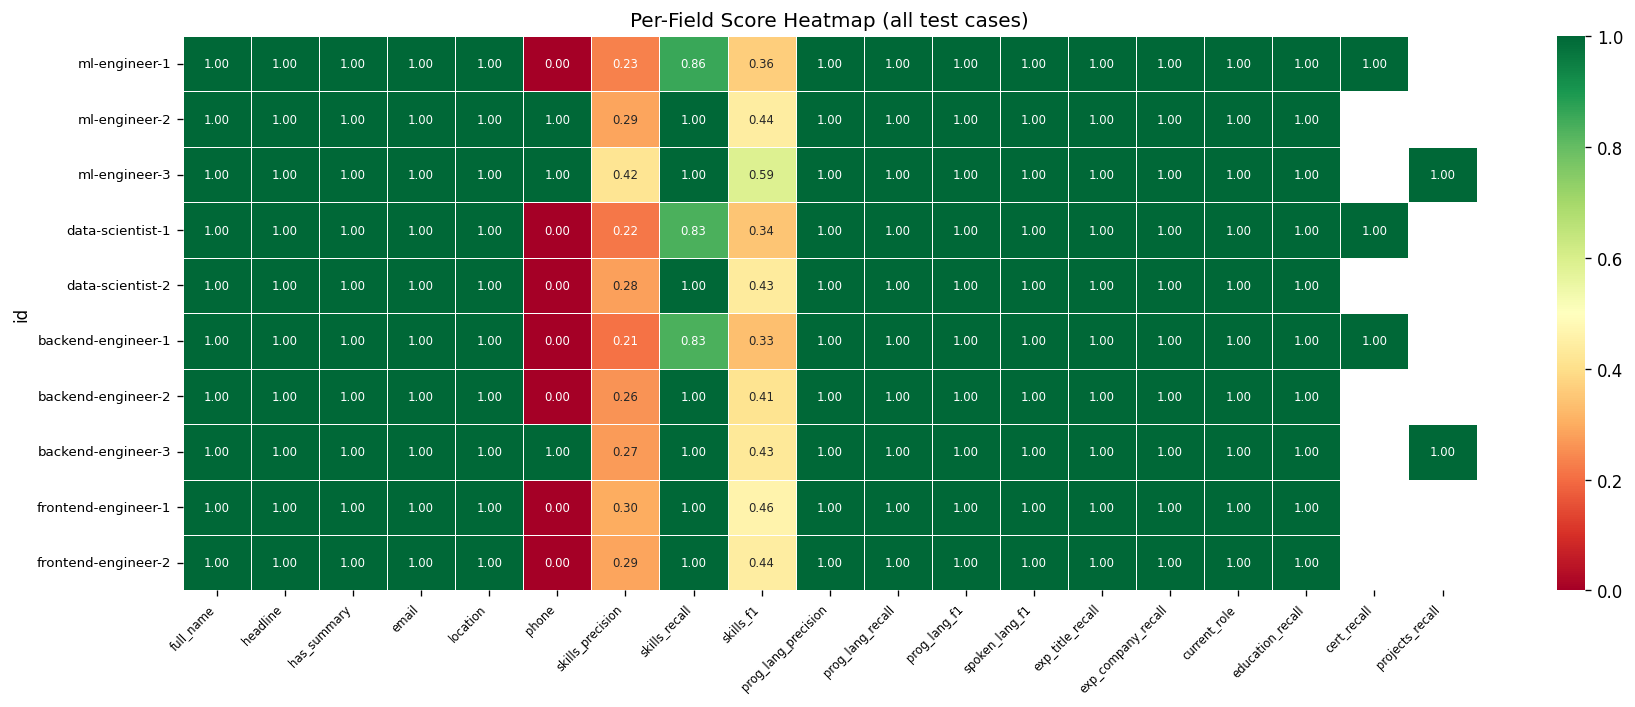

Heatmap saved to eval_heatmap.png


In [ ]:
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "overall_score"]

heatmap_data = df.set_index("id")[numeric_cols].astype(float)

fig, ax = plt.subplots(figsize=(max(12, len(numeric_cols)*0.8), 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size":7})
ax.set_title("Per-Field Score Heatmap (all test cases)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("eval_heatmap.png", bbox_inches="tight")
plt.show()
print("Heatmap saved to eval_heatmap.png")

In [ ]:
print("\n── FIELD-LEVEL DIAGNOSTIC (scores < 0.7) ──")
numeric_df = df[["id"] + [c for c in df.columns if df[c].dtype in [float]]].copy()
threshold = 0.7
for _, row in numeric_df.iterrows():
    weak_fields = [(k,v) for k,v in row.items()
                   if k != "id" and isinstance(v, float) and v < threshold]
    if weak_fields:
        print(f"\n  [{row['id']}]")
        for field, score in sorted(weak_fields, key=lambda x: x[1]):
            print(f"    ⚠  {field:<30} = {score:.3f}")


── FIELD-LEVEL DIAGNOSTIC (scores < 0.7) ──

  [ml-engineer-1]
    ⚠  phone                          = 0.000
    ⚠  skills_precision               = 0.231
    ⚠  skills_f1                      = 0.364

  [ml-engineer-2]
    ⚠  skills_precision               = 0.286
    ⚠  skills_f1                      = 0.444

  [ml-engineer-3]
    ⚠  skills_precision               = 0.417
    ⚠  skills_f1                      = 0.588

  [data-scientist-1]
    ⚠  phone                          = 0.000
    ⚠  skills_precision               = 0.217
    ⚠  skills_f1                      = 0.345

  [data-scientist-2]
    ⚠  phone                          = 0.000
    ⚠  skills_precision               = 0.278
    ⚠  skills_f1                      = 0.435

  [backend-engineer-1]
    ⚠  phone                          = 0.000
    ⚠  skills_precision               = 0.208
    ⚠  skills_f1                      = 0.333

  [backend-engineer-2]
    ⚠  phone                          = 0.000
    ⚠  skills_precision 

## 11. Process Real PDF Resumes from `/testdata`

Upload your PDF resumes to `/testdata` in Colab, then run this section.


In [ ]:
import pathlib

pdf_paths = list(pathlib.Path(TESTDATA_DIR).glob("*.pdf"))
print(f"Found {len(pdf_paths)} PDF(s) in {TESTDATA_DIR}:")
for p in pdf_paths:
    size_kb = p.stat().st_size // 1024
    print(f"  {p.name}  ({size_kb} KB)")

if not pdf_paths:
    print("\nNo PDFs found. Upload resumes to /testdata and re-run.")
    print("   In Colab: Files → Upload → select PDFs, move to /testdata")

Found 10 PDF(s) in /content/testdata:
  10985403.pdf  (21 KB)
  17488801.pdf  (19 KB)
  14049846.pdf  (22 KB)
  12472574.pdf  (32 KB)
  21807224.pdf  (20 KB)
  27040860.pdf  (17 KB)
  20882041.pdf  (21 KB)
  15858254.pdf  (20 KB)
  12518008.pdf  (25 KB)
  25608963.pdf  (24 KB)


In [ ]:
import time
import random
import traceback
from tqdm import tqdm

# ───────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────

MAX_RETRIES = 3
BASE_DELAY = 8
POST_PDF_DELAY = (7, 12)

# ───────────────────────────────────────────────────────────────
# RETRY DETECTION
# ───────────────────────────────────────────────────────────────

RETRYABLE_PATTERNS = [
    "429",
    "503",
    "quota",
    "rate limit",
    "resource exhausted",
    "too many requests",
    "deadline exceeded",
    "internal",
    "temporarily unavailable",
    "service unavailable",
    "timeout",
    "unavailable",
    "high demand",
]


def is_retryable_error(e: Exception) -> bool:
    err_text = str(e).lower()

    return any(
        pattern in err_text
        for pattern in RETRYABLE_PATTERNS
    )


# ───────────────────────────────────────────────────────────────
# EXTRACTION WITH RETRY
# ───────────────────────────────────────────────────────────────

def extract_with_retry(resume_text):
    """
    Robust Gemini retry wrapper.
    Handles:
    - 429 rate limits
    - 503 overloads
    - temporary backend failures
    """

    last_exception = None

    for attempt in range(1, MAX_RETRIES + 1):

        try:
            return extract_structured_resume_data(resume_text)

        except Exception as e:

            last_exception = e

            if not is_retryable_error(e):
                raise

            if attempt >= MAX_RETRIES:
                break

            # Exponential backoff
            delay = BASE_DELAY * (2 ** (attempt - 1))

            # Jitter
            delay += random.uniform(1.0, 3.0)

            print(
                f"   ⚠ Retry {attempt}/{MAX_RETRIES}"
                f" after {delay:.1f}s"
            )

            print(f"   ↳ {type(e).__name__}: {e}")

            time.sleep(delay)

    raise last_exception


# ───────────────────────────────────────────────────────────────
# PDF EXTRACTION LOOP
# ───────────────────────────────────────────────────────────────

pdf_extractions = {}
pdf_raw_texts = {}

if pdf_paths:

    total = len(pdf_paths)

    for idx, pdf_path in enumerate(
        tqdm(pdf_paths, desc="Extracting PDFs"),
        start=1
    ):

        fname = pdf_path.name

        print(f"\n▶ [{idx}/{total}] Processing: {fname}")

        try:

            # Read PDF
            raw_bytes = pdf_path.read_bytes()

            # OCR / markdown conversion
            md_text = pdf_bytes_to_markdown(raw_bytes)

            # Store raw markdown
            pdf_raw_texts[fname] = md_text

            # Structured extraction
            extracted = extract_with_retry(md_text)

            # Save extraction
            pdf_extractions[fname] = extracted

            d = extracted.model_dump(mode="json")

            print(f"   Name     : {d.get('full_name')}")
            print(f"   Email    : {d.get('contact', {}).get('email')}")
            print(f"   Skills   : {len(d.get('skills', []))}")
            print(f"   Exp      : {len(d.get('experience', []))}")
            print("   ✅ Done")

        except Exception as e:

            print(f"   ❌ FINAL FAILURE")
            print(f"   ↳ {type(e).__name__}: {e}")

            traceback.print_exc()

        # Cooldown between resumes
        if idx < total:

            cooldown = random.randint(*POST_PDF_DELAY)

            print(
                f"   ⏳ Cooling down for "
                f"{cooldown}s..."
            )

            time.sleep(cooldown)

print(
    f"\n✅ Processed "
    f"{len(pdf_extractions)}/{len(pdf_paths)} PDFs successfully"
)

Extracting PDFs:   0%|          | 0/10 [00:00<?, ?it/s]


▶ [1/10] Processing: 10985403.pdf
=== Document parser messages ===
                                                                                                                                                                                                                                                            Using Tesseract for OCR processing.

   ⚠ Retry 1/3 after 10.8s
   ↳ ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
   ⚠ Retry 2/3 after 17.0s
   ↳ ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
   Name     : None
   Email    : None
   Skills   : 54
   Exp      : 3
   ✅ Done
   ⏳ Cooling down for 10s...


Extracting PDFs:  10%|█         | 1/10 [00:59<08:51, 59.05s/it]


▶ [2/10] Processing: 17488801.pdf
=== Document parser messages ===
                                                                                                                                                                                                                                                                                                Using Tesseract for OCR processing.

   Name     : None
   Email    : None
   Skills   : 21
   Exp      : 2
   ✅ Done
   ⏳ Cooling down for 7s...


Extracting PDFs:  20%|██        | 2/10 [01:20<04:54, 36.86s/it]

...


▶ [9/10] Processing: 12518008.pdf
=== Document parser messages ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Using Tesseract for OCR processing.

   Name     : None
   Email    : None
   Skills   : 43
   Exp      : 3
   ✅ Done
   ⏳ Cooling down for 12s...


Extracting PDFs:  90%|█████████ | 9/10 [04:10<00:23, 23.79s/it]


▶ [10/10] Processing: 25608963.pdf
=== Document parser messages ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                Using Tesseract for OCR processing.



Extracting PDFs: 100%|██████████| 10/10 [04:17<00:00, 25.72s/it]

   Name     : None
   Email    : None
   Skills   : 27
   Exp      : 6
   ✅ Done

✅ Processed 10/10 PDFs successfully


## 12. LLM-as-Judge Evaluation (OpenRouter / Gemma)

For each PDF, the judge receives:

1. The **raw resume text** (from PDF extraction)
2. The **agent's structured JSON output**

It evaluates 5 dimensions and returns a score 0–10.


In [ ]:
JUDGE_SYSTEM_PROMPT = '''You are an expert evaluator assessing the quality of a resume information extraction system.

You will receive:
1. RAW_RESUME_TEXT: the raw text extracted from a PDF resume
2. EXTRACTION_OUTPUT: the structured JSON produced by an extraction agent

Evaluate the extraction on these 5 dimensions (score each 0–10):

1. COMPLETENESS   — Were all major sections extracted? (name, contact, skills, experience, education, projects, certs)
2. ACCURACY       — Are the extracted values correct and matching the source text?
3. HALLUCINATION  — Did the agent invent facts not present in the resume? (10 = no hallucination, 0 = severe)
4. FIELD_QUALITY  — Are list fields (skills, languages) well-categorised and clean?
5. STRUCTURE      — Is the JSON well-formed and nested correctly (experience bullets, technologies, etc.)?

Return ONLY valid JSON in exactly this format, no prose, no markdown:
{
  "scores": {
    "completeness": <0-10>,
    "accuracy": <0-10>,
    "hallucination": <0-10>,
    "field_quality": <0-10>,
    "structure": <0-10>
  },
  "overall": <weighted mean 0-10, round to 1 decimal>,
  "strengths": ["<strength 1>", "<strength 2>"],
  "weaknesses": ["<weakness 1>", "<weakness 2>"],
  "critical_errors": ["<error>" ] or []
}'''

def llm_judge(raw_text: str, extraction: ResumeExtraction) -> dict:
    "Call OpenRouter judge model and parse response."
    ext_json = json.dumps(extraction.model_dump(mode="json"), indent=2, ensure_ascii=False)

    # Truncate raw text if very long (save tokens)
    max_chars = 6000
    truncated = raw_text[:max_chars] + ("\n...[truncated]" if len(raw_text) > max_chars else "")

    user_msg = f'''RAW_RESUME_TEXT:
<<<
{truncated}
>>>

EXTRACTION_OUTPUT:
<<<
{ext_json}
>>>'''

    judge_model = get_openrouter_judge(temperature=0.1)
    response = judge_model.invoke([
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user",   "content": user_msg},
    ])
    raw = _strip_code_fences(getattr(response, "content", ""))
    return json.loads(raw)

print("LLM-as-judge function defined")

LLM-as-judge function defined


In [ ]:
judge_results = {}

if pdf_extractions:
    print(f"Running LLM judge on {len(pdf_extractions)} PDF(s)...\n")
    for fname, extraction in tqdm(pdf_extractions.items(), desc="LLM Judge"):
        print(f"\nJudging: {fname}")
        raw_text = pdf_raw_texts.get(fname, "")
        try:
            verdict = llm_judge(raw_text, extraction)
            judge_results[fname] = verdict
            scores = verdict.get("scores", {})
            overall = verdict.get("overall", "N/A")
            print(f"   Overall  : {overall}/10")
            print(f"   Scores   : {scores}")
            if verdict.get("strengths"):
                print(f"   Strengths: {verdict['strengths']}")
            if verdict.get("weaknesses"):
                print(f"   Weaknesses: {verdict['weaknesses']}")
            if verdict.get("critical_errors"):
                print(f"   Errors: {verdict['critical_errors']}")
        except Exception as e:
            print(f"   ❌ Judge failed: {e}")
            traceback.print_exc()
            judge_results[fname] = {"error": str(e), "overall": None}
else:
    print("No PDFs processed — judge will run once PDFs are loaded.")

Running LLM judge on 10 PDF(s)...



LLM Judge:   0%|          | 0/10 [00:00<?, ?it/s]


Judging: 10985403.pdf


LLM Judge:  10%|█         | 1/10 [00:03<00:31,  3.55s/it]

   Overall  : 8.6/10
   Scores   : {'completeness': 9, 'accuracy': 8, 'hallucination': 10, 'field_quality': 8, 'structure': 8}
   Strengths: ['Good extraction of skills and certifications.', 'Successfully parsed experience details including dates and company names.', 'No hallucinations detected.']
   Weaknesses: ['Missing full name and contact information.', 'Experience description bullets are often overly verbose and include extraneous information (e.g., institute names within bullet points).', 'Education start dates are missing.']

Judging: 17488801.pdf


...

   Overall  : 8.4/10
   Scores   : {'completeness': 9, 'accuracy': 8, 'hallucination': 10, 'field_quality': 7, 'structure': 8}
   Strengths: ['Successfully extracted most key sections (experience, education, skills).', 'No hallucination detected - all information is present in the source document.']
   Weaknesses: ['Missing full name and contact information.', 'Skills list is a bit noisy and contains redundant entries.', 'Experience description bullets are very long and could be better segmented.']

Judging: 12518008.pdf


LLM Judge:  90%|█████████ | 9/10 [00:41<00:04,  4.33s/it]

   Overall  : 8.4/10
   Scores   : {'completeness': 9, 'accuracy': 8, 'hallucination': 10, 'field_quality': 7, 'structure': 8}
   Strengths: ['Good extraction of experience details including dates and descriptions', 'No hallucination detected', 'Successfully extracted certifications and education']
   Weaknesses: ['Skills list is noisy and contains redundant entries', 'Contact information is missing', 'Company names are not consistently extracted for all experience entries']

Judging: 25608963.pdf


LLM Judge: 100%|██████████| 10/10 [00:44<00:00,  4.45s/it]

   Overall  : 8.0/10
   Scores   : {'completeness': 8, 'accuracy': 7, 'hallucination': 10, 'field_quality': 7, 'structure': 8}
   Strengths: ['Good extraction of experience details', 'No hallucination detected', 'Well-structured JSON format']
   Weaknesses: ['Missing full name and contact information', 'Skills list could be more refined and categorized', 'Some description bullets are very long and unformatted']



LLM-AS-JUDGE FINAL REPORT
        file  overall  completeness  accuracy  hallucination  field_quality  structure
10985403.pdf    8.600             9         8             10              8          8
17488801.pdf    8.000             8         7             10              7          8
14049846.pdf    7.400             8         7              9              7          6
12472574.pdf    7.600             8         7              9              6          8
21807224.pdf    8.200             8         8             10              7          8
27040860.pdf    8.000             8         7             10              7          8
20882041.pdf    8.600             9         8             10              7          9
15858254.pdf    8.400             9         8             10              7          8
12518008.pdf    8.400             9         8             10              7          8
25608963.pdf    8.000             8         7             10              7          8


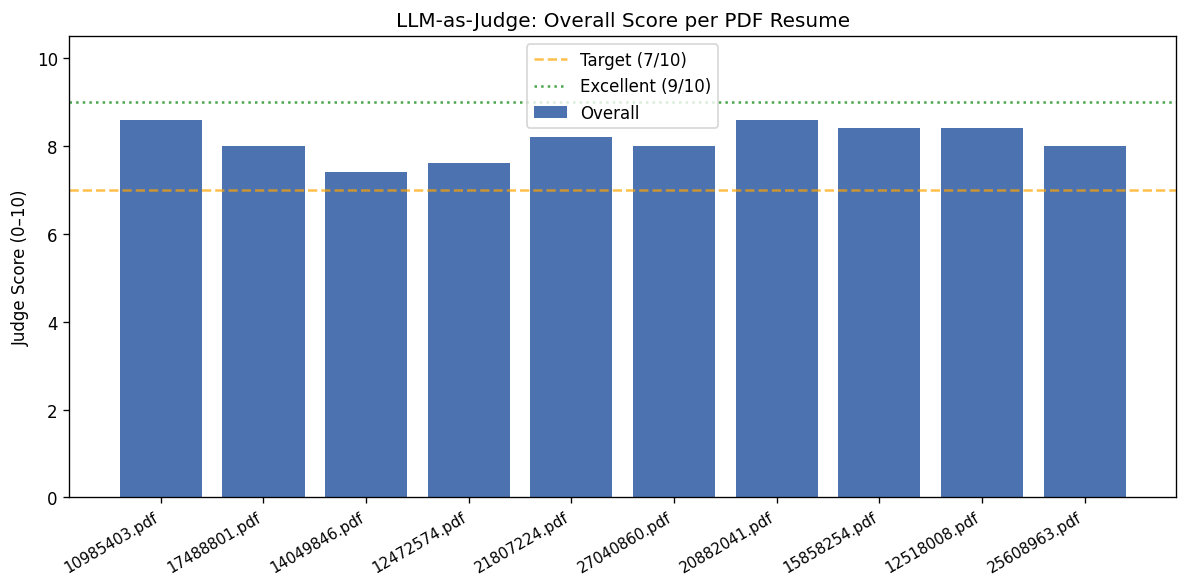

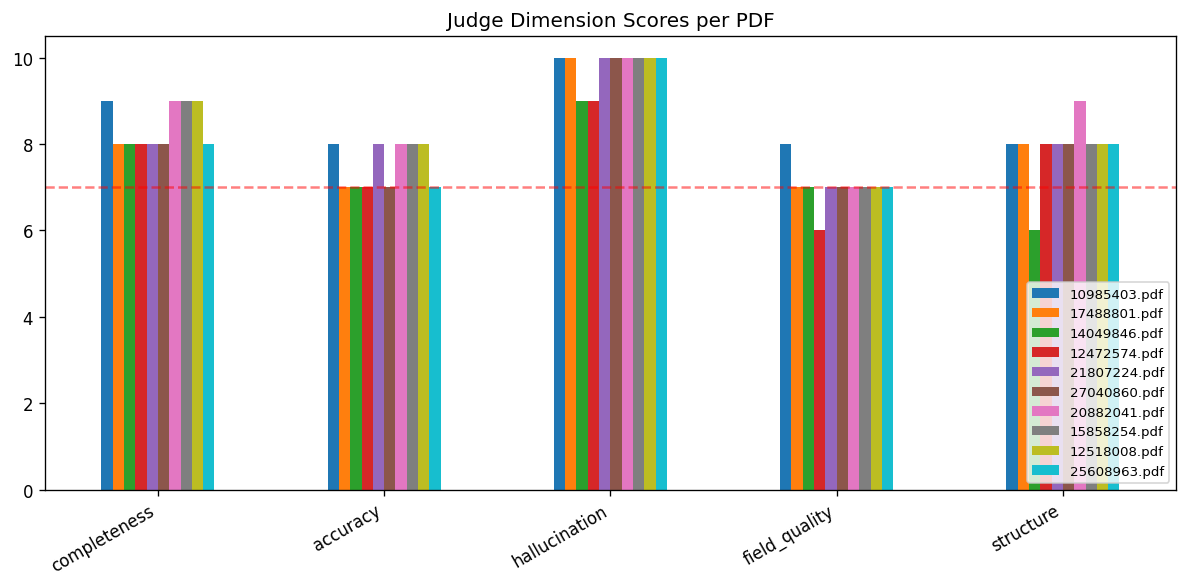

In [ ]:
if judge_results:
    print("\n" + "="*70)
    print("LLM-AS-JUDGE FINAL REPORT")
    print("="*70)

    judge_rows = []
    for fname, verdict in judge_results.items():
        if "error" in verdict:
            judge_rows.append({"file": fname, "overall": None,
                                "completeness":None,"accuracy":None,
                                "hallucination":None,"field_quality":None,"structure":None})
            continue
        s = verdict.get("scores", {})
        judge_rows.append({
            "file": fname,
            "overall":      verdict.get("overall"),
            "completeness": s.get("completeness"),
            "accuracy":     s.get("accuracy"),
            "hallucination":s.get("hallucination"),
            "field_quality":s.get("field_quality"),
            "structure":    s.get("structure"),
        })

    judge_df = pd.DataFrame(judge_rows)
    print(judge_df.to_string(index=False))

    # Radar-style bar chart
    dim_cols = ["completeness","accuracy","hallucination","field_quality","structure"]
    dim_cols = [c for c in dim_cols if c in judge_df.columns]
    valid_judge = judge_df.dropna(subset=["overall"])
    if not valid_judge.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        x = range(len(valid_judge))
        ax.bar(x, valid_judge["overall"], color="#4C72B0", label="Overall")
        ax.axhline(7, color="orange", linestyle="--", alpha=0.7, label="Target (7/10)")
        ax.axhline(9, color="green",  linestyle=":",  alpha=0.7, label="Excellent (9/10)")
        ax.set_xticks(list(x))
        ax.set_xticklabels(valid_judge["file"], rotation=30, ha="right", fontsize=9)
        ax.set_ylim(0, 10.5)
        ax.set_ylabel("Judge Score (0–10)")
        ax.set_title("LLM-as-Judge: Overall Score per PDF Resume")
        ax.legend()
        plt.tight_layout()
        plt.savefig("judge_scores.png", bbox_inches="tight")
        plt.show()

        # Dimension breakdown
        avail_dims = [c for c in dim_cols if c in valid_judge.columns]
        if avail_dims and len(valid_judge) > 0:
            fig2, ax2 = plt.subplots(figsize=(10, 5))
            valid_judge.set_index("file")[avail_dims].T.plot(kind="bar", ax=ax2, colormap="tab10")
            ax2.set_title("Judge Dimension Scores per PDF")
            ax2.set_xticklabels(avail_dims, rotation=30, ha="right")
            ax2.set_ylim(0, 10.5)
            ax2.axhline(7, color="red", linestyle="--", alpha=0.5)
            ax2.legend(loc="lower right", fontsize=8)
            plt.tight_layout()
            plt.savefig("judge_dimensions.png", bbox_inches="tight")
            plt.show()
else:
    print("No judge results yet — run the PDF processing section first.")

## 13. Final Combined Report


In [ ]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

# Hardcoded test case summary
if 'df' in dir() and not df.empty:
    ok_df = df[df["status"]=="ok"]
    print(f"\nHardcoded Test Cases ({len(df)} total, {len(ok_df)} successful):")
    print(f"   Mean overall score   : {ok_df['overall_score'].mean():.4f}")
    print(f"   Mean skills F1       : {ok_df['skills_f1'].mean():.4f}")
    print(f"   Mean prog_lang F1    : {ok_df['prog_lang_f1'].mean():.4f}")
    print(f"   Mean exp title recall: {ok_df['exp_title_recall'].mean():.4f}")
    print(f"   Mean edu recall      : {ok_df['education_recall'].mean():.4f}")
    print(f"\n   Breakdown by role:")
    for role, grp in ok_df.groupby("role"):
        print(f"     {role:<22}  overall={grp['overall_score'].mean():.3f}  n={len(grp)}")

# LLM judge summary
if judge_results:
    valid = [(f,v) for f,v in judge_results.items() if v.get("overall") is not None]
    if valid:
        mean_judge = sum(v["overall"] for _,v in valid) / len(valid)
        print(f"\nLLM-as-Judge ({len(valid)} PDFs evaluated):")
        print(f"   Mean overall score   : {mean_judge:.1f}/10")
        for dim in ["completeness","accuracy","hallucination","field_quality","structure"]:
            scores = [v.get("scores",{}).get(dim) for _,v in valid if v.get("scores",{}).get(dim) is not None]
            if scores: print(f"   Mean {dim:<18}: {sum(scores)/len(scores):.1f}/10")

print("\n" + "="*70)
print("Evaluation notebook complete.")


FINAL SUMMARY

Hardcoded Test Cases (10 total, 10 successful):
   Mean overall score   : 0.8978
   Mean skills F1       : 0.4257
   Mean prog_lang F1    : 1.0000
   Mean exp title recall: 1.0000
   Mean edu recall      : 1.0000

   Breakdown by role:
     backend-engineer        overall=0.896  n=3
     data-scientist          overall=0.881  n=2
     frontend-engineer       overall=0.885  n=2
     ml-engineer             overall=0.919  n=3

LLM-as-Judge (10 PDFs evaluated):
   Mean overall score   : 8.1/10
   Mean completeness      : 8.4/10
   Mean accuracy          : 7.5/10
   Mean hallucination     : 9.8/10
   Mean field_quality     : 7.0/10
   Mean structure         : 7.9/10

Evaluation notebook complete.
